<a href="https://colab.research.google.com/github/Sri-Ram-git/CI-CD_nodeapp/blob/main/edgedetection_kernel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Image Shape: (300, 300, 1)


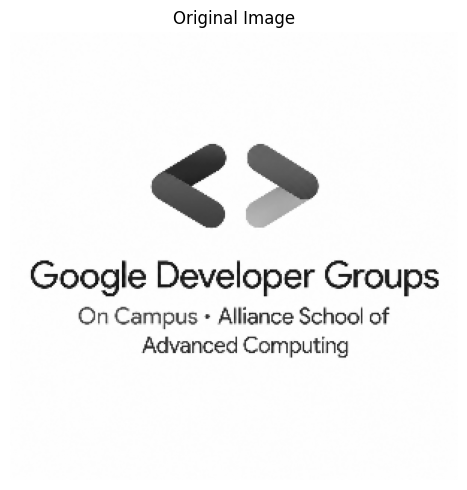

After Convolution Shape: (1, 300, 300, 1)


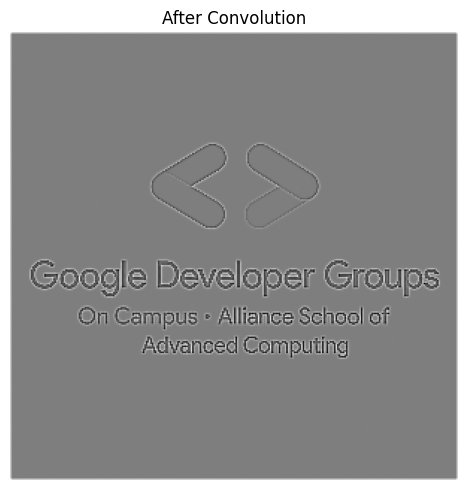

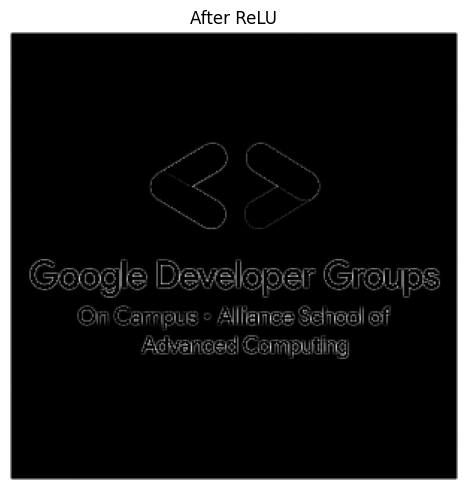

After Pooling Shape: (1, 150, 150, 1)


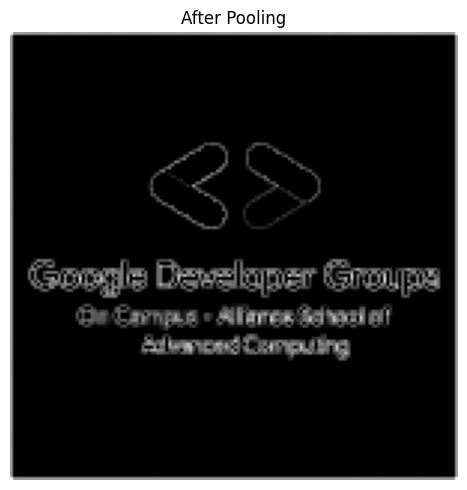

After Flattening Shape: (1, 22500)
After Reshaping Shape: (1, 22500)
After Dense Layer Shape: (1, 10)
Dense Layer Weights Shape: (22500, 10)
Dense Layer Bias Shape: (10,)
Dense Layer Output: tf.Tensor(
[[  69.00037  106.32567  201.09467  190.44272 -418.73868  141.51955
   655.5809   -86.94604 -263.8548   340.3504 ]], shape=(1, 10), dtype=float32)


In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)
image_path = "/content/gdg logo.png"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()
relu_output = tf.nn.relu(conv_output)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU")
plt.axis('off')
plt.show()
pool_output = tf.nn.pool(
    input=relu_output,
    window_shape=(2, 2),
    pooling_type='MAX',
    strides=(2, 2),
    padding='SAME'
)
print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Pooling")
plt.axis('off')
plt.show()
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flattening Shape:", flatten_output.shape)
flatten_output = tf.reshape(flatten_output, [1, -1])

print("After Reshaping Shape:", flatten_output.shape)
dense_layer = tf.keras.layers.Dense(10)
dense_output = dense_layer(flatten_output)

print("After Dense Layer Shape:", dense_output.shape)
print("Dense Layer Weights Shape:", dense_layer.weights[0].shape)
print("Dense Layer Bias Shape:", dense_layer.weights[1].shape)
print("Dense Layer Output:", dense_output)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving gdg logo.png to gdg logo.png
